# EDA — Telco Customer Churn

Trabalho de exploração sobre o arquivo `data/raw/Telco_customer_churn.xlsx`, no contexto do Tech Challenge (fase de produtização). O objetivo aqui não é já fechar o modelo, é perceber o que o Excel realmente traz: quantas linhas temos, se há buracos ou valores estranhos, como o churn se distribui e que variáveis parecem puxar mais para um lado ou para o outro.

A primeira célula de código trata do caminho: funciona tanto se você abrir o notebook com a pasta de trabalho na **raiz do repositório** como se você estiver dentro de `notebooks/` — nesse caso sobe um nível e procura `data/raw/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "raw" / "Telco_customer_churn.xlsx"
assert DATA_PATH.is_file(), f"Dataset não encontrado: {DATA_PATH}"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4.5)

In [2]:
df = pd.read_excel(DATA_PATH)
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


Depois de rodar o `head()`, vale dar uma uma olhada nas colunas: há muito campo categórico em texto (`Yes`/`No`, nomes de serviços), alguns inteiros que na prática são binários (`Senior Citizen`, `Zip Code` é número mas se comporta como ID regional), e o alvo explícito em `Churn Label`. O `Churn Value` já vem numérico — confirmar no dicionário de dados (se existir) se é redundante do `Churn Label` antes de usar isso como feature.

## 1. Volume e estrutura

Começo sempre por isto porque dá contexto imediato. O `shape` diz quantos clientes (linhas) e quantos campos (colunas) temos; a memória em MiB dá uma ideia se estamos falando de algo que cabe confortavelmente em RAM no seu laptop. Os `dtypes` importam porque misturar `object` com número sem critério costuma dar problemas depois no `sklearn` — e aqui já aparece um caso típico: `Total Charges` vem como texto/objeto mesmo parecendo valor monetário.

Também vale a pena ver se `CustomerID` se repete. Em princípio cada linha devia ser um cliente; se houver duplicados, ou corrigimos na origem ou decidimos agregar antes de treinar.

In [3]:
print("Shape (linhas, colunas):", df.shape)
print("Memória aproximada (MiB):", df.memory_usage(deep=True).sum() / 1024**2)
print("\nDuplicados em CustomerID:", df["CustomerID"].duplicated().sum())
df.dtypes

Shape (linhas, colunas): (7043, 33)
Memória aproximada (MiB): 9.303627014160156

Duplicados em CustomerID: 0


CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

### O que retirar do bloco de volume

O `shape` confirma a ordem de grandeza (milhares de linhas), acima do mínimo pedido no desafio (5000). A memória em MiB indica se cabe tudo em RAM em um laptop comum.

Se duplicados em `CustomerID` forem zero, há uma linha por cliente; se não, é preciso limpar ou agregar antes de treinar.

A lista de `dtypes` mostra quantas colunas são `object` — cada uma vai precisar de *encoding*, conversão explícita ou exclusão no `sklearn`.


## 2. Valores ausentes e campos problemáticos

A tabela de faltantes (`isna`) diz logo se há colunas “furadas” à cabeça. Nem sempre o Excel mostra o problema assim: às vezes o valor existe mas é um espaço ou um traço, e o pandas conta como preenchido.

Foi por isso que forcei `Total Charges` para número com `errors="coerce"`. O que não for número válido passa a `NaN` e conseguimos isolar essas linhas e analisá-las no contexto (por exemplo `Tenure Months` a zero e `Monthly Charges` preenchido — perfil de cliente novo onde o total acumulado ainda não foi calculado). São poucas linhas no nosso arquivo, mas convém decidir com calma se as imputamos, recalculamos ou retiramos do treino, em vez de deixar o modelo “engolir” lixo silencioso.

In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
qualidade = pd.DataFrame({"faltantes": missing, "%": missing_pct})
qualidade[qualidade["faltantes"] > 0]

,faltantes,%
Churn Reason,5174,73.46


### Leitura da tabela de faltantes

Se a tabela filtrada sair vazia, o pandas não encontrou `NaN`. Isso alivia, mas **não** substitui a conversão de texto: `Total Charges` pode estar "preenchido" com espaço e mesmo assim falhar como número.

Se aparecerem colunas com muitos faltantes, anote nome e % — candidatas a imputação, coluna derivada ou remoção, e isso deve ir ao README ou *Model Card*.


In [5]:
df["Total Charges numeric"] = pd.to_numeric(df["Total Charges"], errors="coerce")
bad_mask = df["Total Charges numeric"].isna()
print("Linhas com Total Charges inválido ou vazio:", bad_mask.sum())
if bad_mask.any():
    display(df.loc[bad_mask, ["CustomerID", "Tenure Months", "Monthly Charges", "Total Charges", "Churn Label"]].head(15))

Linhas com Total Charges inválido ou vazio: 11


,CustomerID,Tenure Months,Monthly Charges,Total Charges,Churn Label
2234,4472-LVYGI,0,52.55,,No
2438,3115-CZMZD,0,20.25,,No
2568,5709-LVOEQ,0,80.85,,No
2667,4367-NUYAO,0,25.75,,No
2856,1371-DWPAZ,0,56.05,,No
4331,7644-OMVMY,0,19.85,,No
4687,3213-VVOLG,0,25.35,,No
5104,2520-SGTTA,0,20.00,,No
5719,2923-ARZLG,0,19.70,,No
6772,4075-WKNIU,0,73.35,,No


### Linhas em que `Total Charges` não é número

O número impresso (falhas na conversão) é pequeno em relação ao total, mas não é zero. Veja o `display`: muitas vezes o padrão é `Tenure Months` a zero com `Monthly Charges` já definido — cliente novo sem total acumulado no Excel.

Para o pipeline, decida: imputar com regra (ex. produto *tenure* × mensalidade quando fizer sentido), ou remover e documentar quantas linhas saíram. Não deixe `object` nem `NaN` aqui sem decisão explícita.


## 3. Variável-alvo (`Churn Label`)

O alvo está em texto (`Yes` / `No`). Para modelagem vamos mapear para 0/1, mas antes vale olhar o desequilíbrio: se a classe “churn” for minoritária (o que é normal neste tipo de base), uma accuracy alta pode ser enganadora — o modelo pode acertar só a dizer “não churn” para tudo.

Por isso, mais tarde, faz sentido olhar **precision/recall** por classe, **F1** na classe positiva, ou **PR-AUC**, além da ROC. O gráfico ao lado dá uma leitura rápida: contagem absoluta e porcentagem por classe, para não perder a noção da escala nem da proporção.

,contagem,%
Churn Label,,
No,5174,73.46
Yes,1869,26.54


C:\Users\Primodeckers\AppData\Local\Temp\ipykernel_27236\3892922345.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target, order=["No", "Yes"], ax=ax[0], palette="Set2")


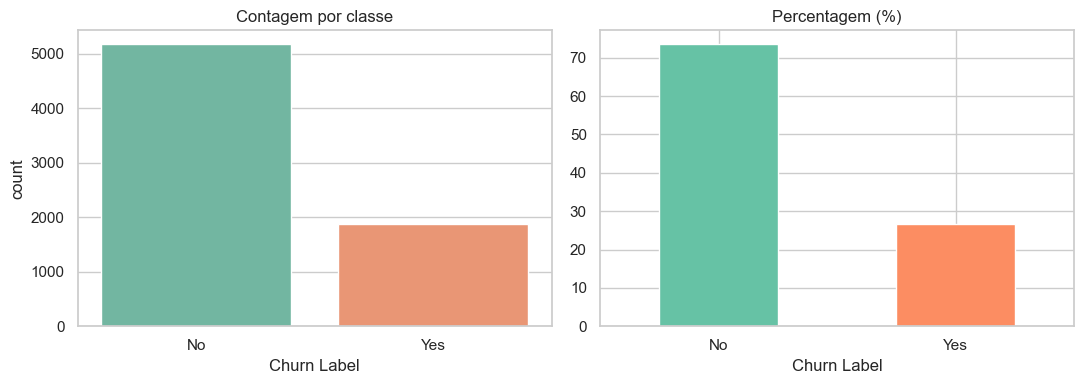

In [6]:
target = "Churn Label"
vc = df[target].value_counts()
prop = df[target].value_counts(normalize=True).round(4) * 100
display(pd.DataFrame({"contagem": vc, "%": prop}))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x=target, order=["No", "Yes"], ax=ax[0], palette="Set2")
ax[0].set_title("Contagem por classe")
prop.reindex(["No", "Yes"]).plot(kind="bar", ax=ax[1], color=["#66c2a5", "#fc8d62"])
ax[1].set_title("Percentagem (%)")
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

### Leitura dos dois gráficos do alvo

O gráfico da **esquerda** (contagens absolutas) dá escala. O da **direita** (percentagens) mostra o **desequilíbrio**: a barra de `Yes` mais curta indica churn minoritário — típico em telecom.

Consequência: um modelo que prevê sempre `No` ainda pode ter *accuracy* aparentemente boa. Mais tarde convém acompanhar **recall** na classe churn, **F1** na positiva ou **PR-AUC**, e não ficar só pela ROC se o desequilíbrio for forte. Os valores exatos estão na tabela acima dos gráficos.


## 4. Variáveis numéricas (distribuições)

O `describe()` resume mediana, dispersão e outliers grossos. Os histogramas com curva (`kde`) ajudam a ver se a variável é assimétrica, bimodal, etc. Os boxplots separados por `Churn Label` são úteis para ver se churners tendem a ter mensalidade mais alta, permanência mais baixa, e por aí fora — são pistas, não prova causal.

Atenção redobrada a colunas como `Churn Value`, `Churn Score` e `CLTV`: pelo nome, podem estar em demasia coladas ao resultado ou a políticas internas da operadora. Se forem construídas **depois** de o cliente já ter churnado, colocar isso como *feature* é vazamento de informação e o modelo fica bonito no notebook e mentiroso em produção. Só entram no pipeline depois de alguém do negócio (ou a documentação da base) confirmar o que significam e **quando** são conhecidas.

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000
Total Charges numeric,7032.0,2283.300441,2266.771362,18.800000,401.450000,1397.475000,3794.737500,8684.800000


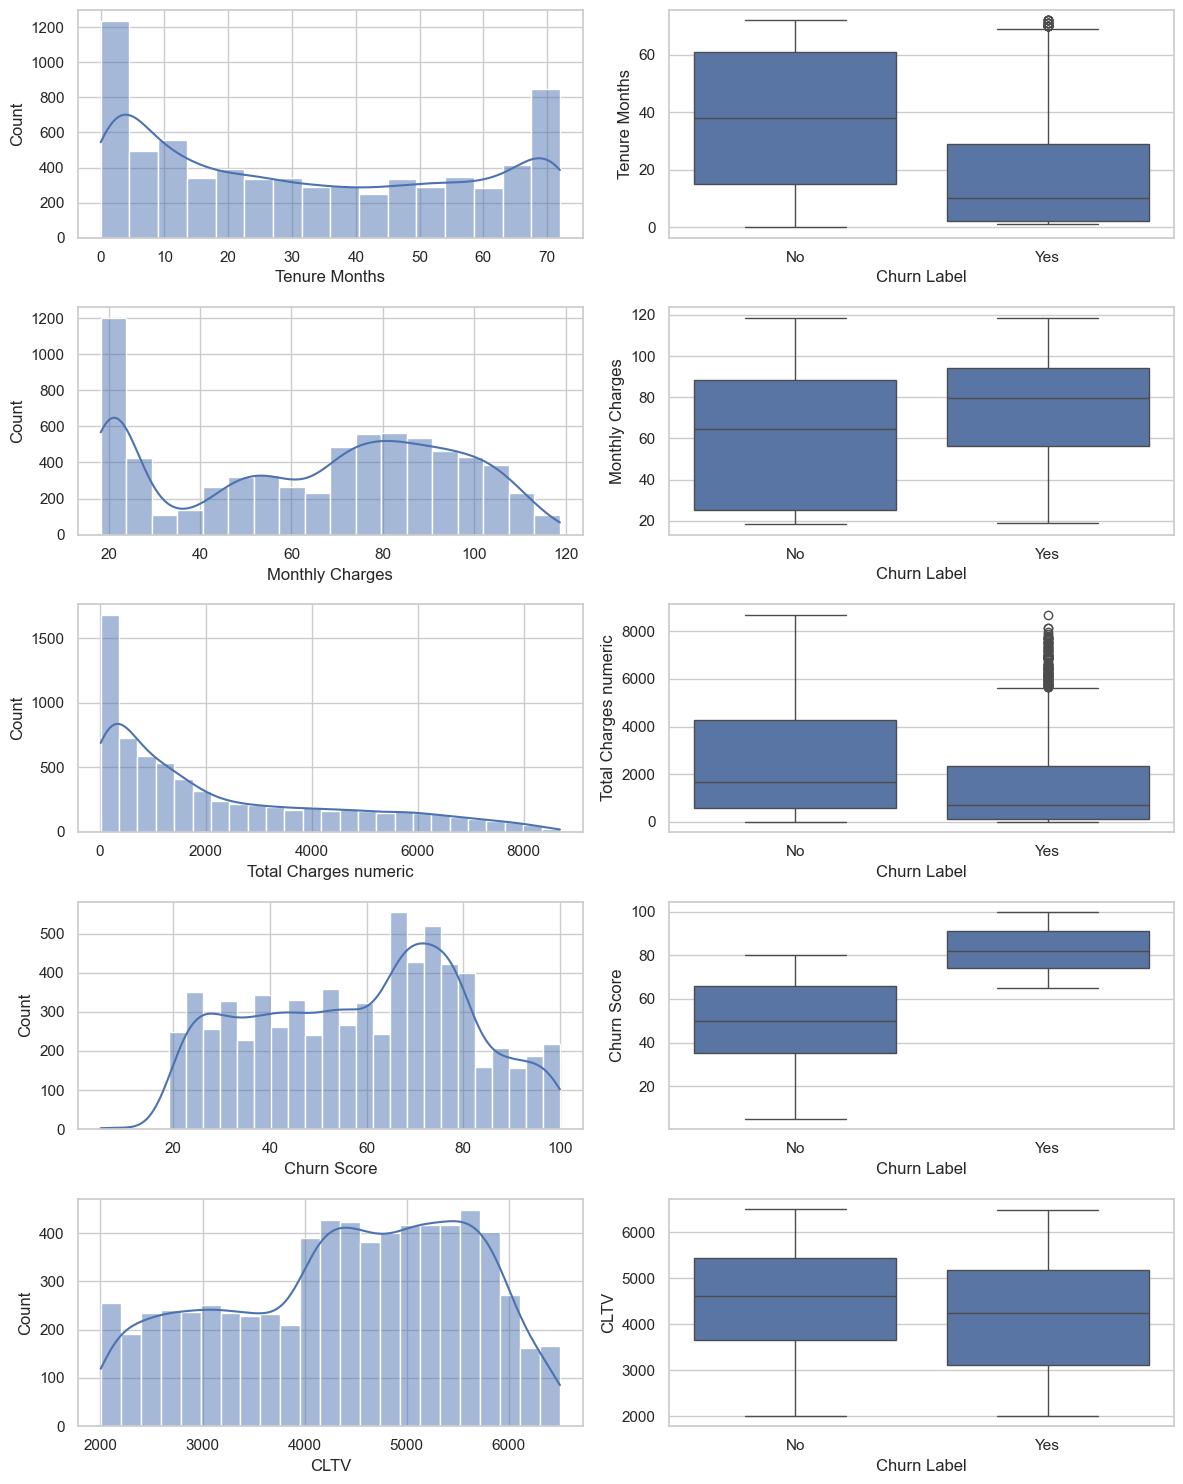

In [7]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
display(df[num_cols].describe().T)

plot_nums = [c for c in ["Tenure Months", "Monthly Charges", "Total Charges numeric", "Churn Score", "CLTV"] if c in df.columns]
nrows = max(len(plot_nums), 1)
fig, axes = plt.subplots(nrows, 2, figsize=(12, 3 * nrows))
axes = np.atleast_2d(axes)
for i, col in enumerate(plot_nums):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i, 0])
    sns.boxplot(data=df, x=target, y=col, ax=axes[i, 1], order=["No", "Yes"])
plt.tight_layout()
plt.show()

### Histogramas e boxplots lado a lado

No **histograma** (coluna da esquerda em cada fila) dá para ver a forma da distribuição: caudas, picos, outliers visíveis. A curva `kde` é um suavizado — ajuda à leitura, não substitui testes formais.

No **boxplot** (direita), a mesma variável por `Churn Label`: compara medianas e dispersão. Diferenças claras sugerem poder preditivo, mas **não provam causa**. Reforço: `Churn Score` e `CLTV` podem estar em demasia alinhados ao resultado; vale confirmar com o negócio antes de usar como *feature*.


## 5. Variáveis categóricas relevantes

Não desenhei gráfico para todas as categorias: `City`, `Zip Code`, `Lat Long` explodem cardinalidade e muitas vezes trazem ruído ou risco de memorizar regiões em vez de padrão de serviço. `Churn Reason` é quase sempre pós-evento — útil para narrativa de negócio, perigoso como *input* do modelo se for consequência do churn.

Ficamos com um conjunto que costuma aparecer nos relatórios de telecom: tipo de contrato, internet, pagamento, papel *paperless*, composição do agregado familiar e alguns extras de produto (segurança online, *streaming*, etc.). O gráfico mostra, para cada categoria, a porcentagem de `Yes`/`No` **dentro** dessa categoria (normalização por linha do *crosstab*), para comparar perfis entre si com mais justiça do que contar brutos.

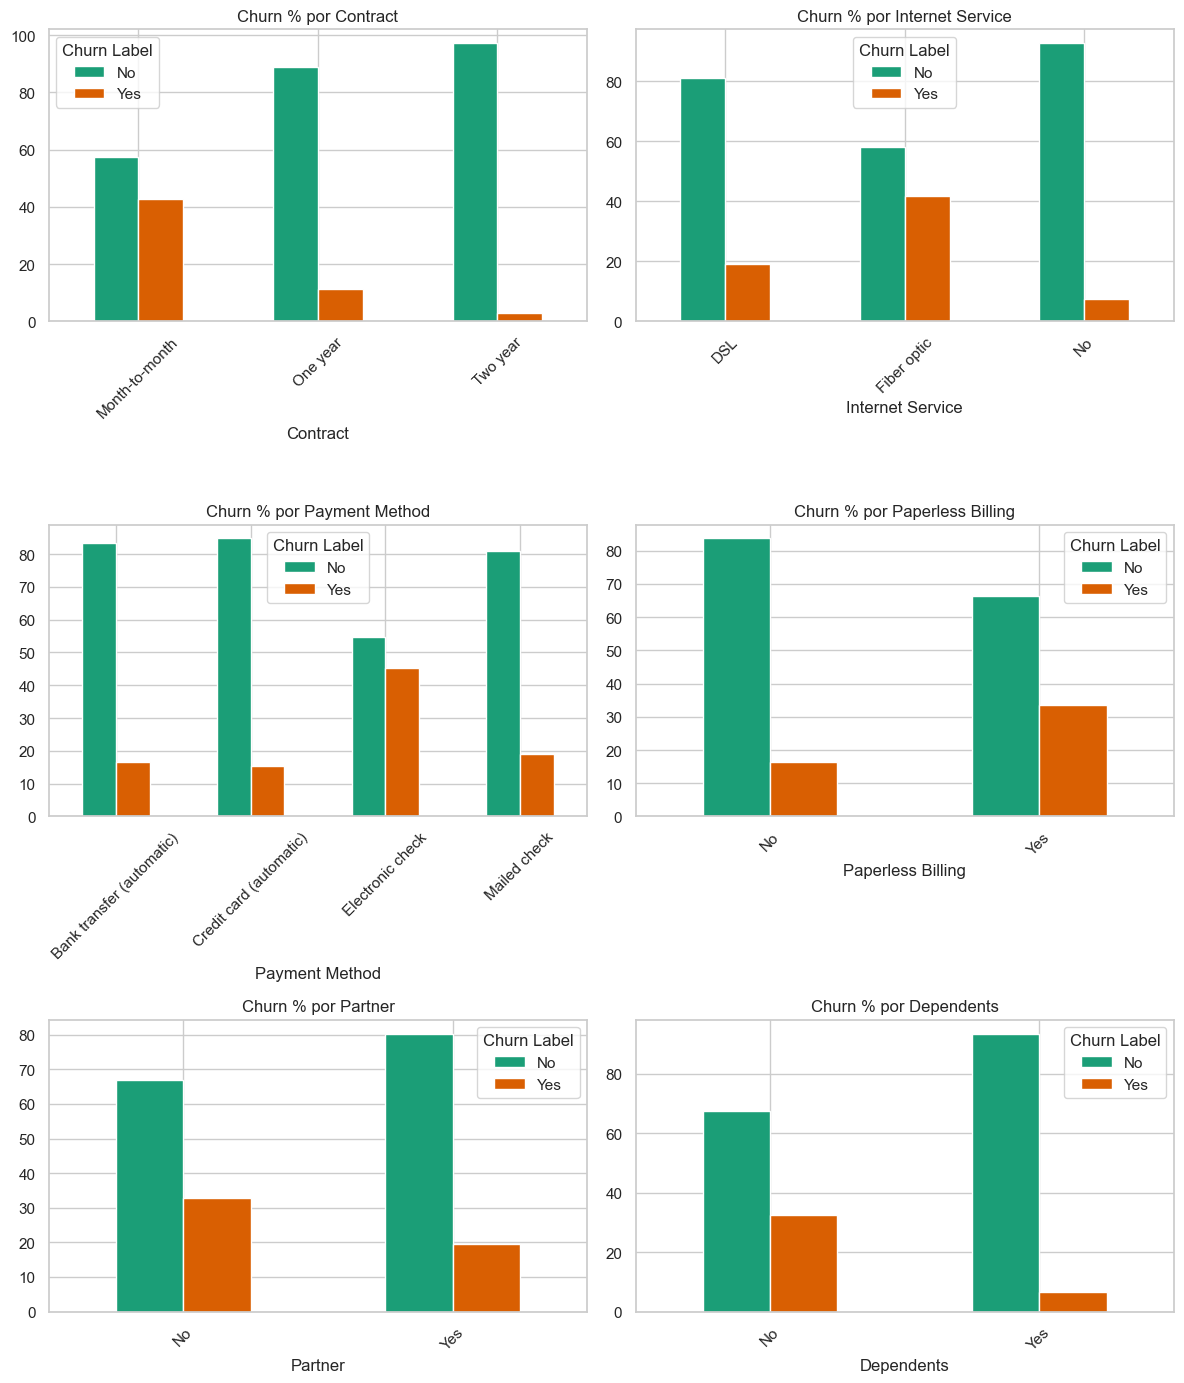

In [8]:
cat_focus = [
    "Contract",
    "Internet Service",
    "Payment Method",
    "Paperless Billing",
    "Partner",
    "Dependents",
] + [c for c in ["Online Security", "Tech Support", "Streaming TV"] if c in df.columns]

fig, axes = plt.subplots(3, 2, figsize=(12, 14))
axes = axes.flatten()
for ax, col in zip(axes, cat_focus[:6]):
    ct = pd.crosstab(df[col], df[target], normalize="index") * 100
    ct.plot(kind="bar", ax=ax, stacked=False, color=["#1b9e77", "#d95f02"])
    ax.set_title(f"Churn % por {col}")
    ax.set_xlabel(col)
    ax.legend(title=target)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### Gráficos de categorias (porcentagem dentro de cada grupo)

Cada painel cruza uma categoria com o alvo; as barras estão em **porcentagem dentro daquela linha do *crosstab*** (normalização por índice). Assim você compara, por exemplo, *Month-to-month* com contrato longo sem ser enganado pelo tamanho bruto do grupo.

Barras de `Yes` muito mais altas indicam associação forte com churn — boas candidatas a *feature* depois do *encoding*. Categorias com poucas observações podem oscilar à sorte; nesse caso cruza com contagens absolutas antes de fechar conclusões.


## 6. Correlações (numéricas)

O heatmap resume relações lineares grosso modo. Correlação não implica causa; serve para pegar pares muito colinearizados (que podem dar instabilidade em regressão) ou associações fortes com o alvo **se** incluirmos variáveis que forem legítimas no momento da predição.

Deixei `annot=False` porque, com muitas variáveis, o quadriculado fica ilegível — o importante é ver blocos quentes/frios. Se precisar de números exatos para uma dupla específica, filtre no `corr` na célula ou exporte para uma tabela pequena.

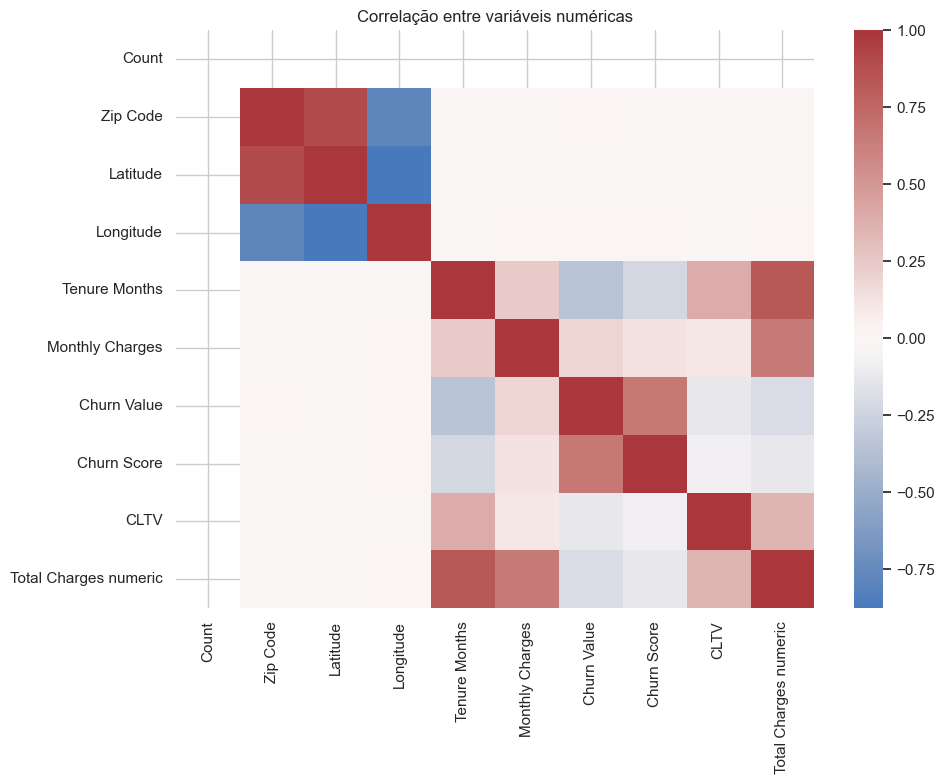

In [9]:
df_num = df[num_cols].copy()
if "Total Charges numeric" in df.columns:
    df_num["Total Charges numeric"] = df["Total Charges numeric"]
corr = df_num.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="vlag", center=0)
plt.title("Correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

### Como ler o heatmap de correlações

A matriz mede associação **linear** entre pares de variáveis numéricas (inclui `Total Charges numeric` depois da conversão). Blocos quentes (tons avermelhados nesta escala `vlag`) indicam correlação positiva forte; tons azulados, negativa forte.

Serve sobretudo para pegar **redundância** entre *features* (duas variáveis quase iguais ao longo da matriz). O mapa **não** mostra relações não lineares nem interações. Se uma variável tiver correlação muito alta com `Churn Value` ou `Churn Score`, volta à pergunta de *leakage*.


## 7. Fecho: o que isto muda na prática

Com o que vimos acima, dá para escrever umas decisões em voz alta antes de abrir o `sklearn`.

As linhas em que `Total Charges` não converteu para número são poucas em relação ao total (~7043 linhas), mas não dá para fingir que não existem: ou imputamos com regra de negócio (ex.: `Tenure Months * Monthly Charges` quando `Tenure` > 0, ou 0 quando faz sentido para cliente novo), ou removemos com registro no README de quantas saíram. O importante é não deixar o `object` original entrar no pipeline.

Para a lista de colunas de treino, eu deixaria de fora, até haver confirmação: identificadores puros (`CustomerID`), coordenadas/localização fina se não forem requisito de produto, e qualquer campo que seja consequência direta do churn (`Churn Reason`, possivelmente scores “suspeitos de serem *leakage*”). O resto passa por *One-Hot* ou *OrdinalEncoder* conforme a variável, dentro de um `ColumnTransformer`, com a mesma transformação no treino e na API.

Por fim, o alvo passa a binário (`Yes` → 1) e a validação cruzada deve ser **estratificada** para cada *fold* ter a mesma mistura aproximada de churn. A célula seguinte só fixa uns números de referência (contagens e porcentagem de `Yes`) para consultar rápido quando voltarmos a este notebook daqui a uns dias.

In [10]:
# Rodapé: quatro números para não depender da memória quando formos ao MLflow / relatório
resumo = {
    "n_linhas": len(df),
    "n_cols": df.shape[1],
    "churn_yes_%": float((df[target] == "Yes").mean() * 100),
    "total_charges_problemas": int(bad_mask.sum()),
}
pd.Series(resumo)

n_linhas                   7043.000000
n_cols                       34.000000
churn_yes_%                  26.536987
total_charges_problemas      11.000000
dtype: float64

### Leitura do rodapé numérico

Estes quatro números fecham o notebook de forma objetiva: tamanho da base, número de colunas, **porcentagem de `Yes` no churn** e quantas linhas ficaram com `Total Charges` inválido após a conversão.

Se o `churn_yes_%` coincidir (a menos de arredondamento) com o que você calculou no bloco do alvo, é sinal de que o `df` não foi sobrescrito por engano no meio da análise. O contador de `Total Charges` deve bater com o número de linhas do `bad_mask` — útil para copiar para o MLflow (*tags* ou descrição do *dataset*) ou para o relatório da entrega.
